# 주간 아파트 매매·전세 지수 분석 (KB 데이터)

**목표**  
- 매매지수 상승(시세 상승)이 큰 지역을 찾고  
- 그 중 전세지수는 상대적으로 덜 오르거나 안정적인 지역을 찾은 뒤  
- **전세를 끼고 매수했을 때(전세 레버리지)**의 **자기자본 수익률(ROE)** 을 5년/10년 기준으로 계산합니다.

> 지수는 실제 가격이 아니라 **지수(Index)** 이지만, 같은 기준으로 산출된 매매/전세 지수의 **비율(전세/매매)** 을 활용하면  
> 전세 레버리지의 방향성과 비교에는 충분히 쓸 수 있습니다.


## 0) 환경 설정 & 라이브러리

In [12]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 한글 폰트 (Windows 기준)
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)


## 1) 데이터 불러오기

In [13]:
df_sale_raw = pd.read_excel("./data/주간 아파트 매매가격지수_20260210.xlsx")
df_rent_raw = pd.read_excel("./data/주간 아파트 전세가격지수_20260210.xlsx")

df_sale_raw.shape, df_rent_raw.shape


((282, 899), (282, 899))

## 2) 데이터 구조 점검 (컬럼/결측/지역명)

In [14]:
df_sale_raw.head(3)

,지역명,2008-04-07 00:00:52,2008-04-14 00:00:52,2008-04-21 00:00:52,2008-04-28 00:00:52,2008-05-05 00:00:52,2008-05-12 00:00:52,2008-05-19 00:00:52,2008-05-26 00:00:52,2008-06-02 00:00:52,2008-06-09 00:00:52,2008-06-16 00:00:52,2008-06-23 00:00:52,2008-06-30 00:00:52,2008-07-07 00:00:52,2008-07-14 00:00:52,2008-07-21 00:00:52,2008-07-28 00:00:52,2008-08-04 00:00:52,2008-08-11 00:00:52,2008-08-18 00:00:52,2008-08-25 00:00:52,2008-09-01 00:00:52,2008-09-08 00:00:52,2008-09-15 00:00:52,...,2025-08-11 00:00:52,2025-08-18 00:00:52,2025-08-25 00:00:52,2025-09-01 00:00:52,2025-09-08 00:00:52,2025-09-15 00:00:52,2025-09-22 00:00:52,2025-09-29 00:00:52,2025-10-13 00:00:52,2025-10-20 00:00:52,2025-10-27 00:00:52,2025-11-03 00:00:52,2025-11-10 00:00:52,2025-11-17 00:00:52,2025-11-24 00:00:52,2025-12-01 00:00:52,2025-12-08 00:00:52,2025-12-15 00:00:52,2025-12-22 00:00:52,2025-12-29 00:00:52,2026-01-05 00:00:52,2026-01-12 00:00:52,2026-01-19 00:00:52,2026-01-26 00:00:52,2026-02-02 00:00:52
0,전국,58.012546,58.088746,58.197535,58.281398,58.355038,58.427476,58.493162,58.553072,58.616457,58.684281,58.745905,58.802806,58.844726,58.891207,58.931078,58.964325,58.977725,58.988577,59.001526,59.023161,59.060476,59.0893,59.116039,59.127395,...,89.671964,89.67241,89.685515,89.708649,89.733195,89.765775,89.815133,89.891714,90.019231,90.152842,90.26271,90.323798,90.384846,90.443855,90.507156,90.563892,90.61607,90.669762,90.723634,90.780566,90.832983,90.896435,90.988497,91.076983,91.171226
1,서울,59.733068,59.88161,60.042211,60.163088,60.278446,60.387011,60.458109,60.525847,60.595353,60.656227,60.696654,60.754457,60.793247,60.816188,60.844399,60.85777,60.856158,60.851878,60.839566,60.830684,60.851299,60.850005,60.853318,60.849386,...,98.7261,98.839442,98.973698,99.145636,99.321403,99.532833,99.868487,100.301588,100.983905,101.648141,102.14984,102.454834,102.71722,102.950405,103.226809,103.430333,103.627722,103.80823,104.024977,104.25149,104.460231,104.710833,105.106874,105.440872,105.776555
2,강북14개구,59.738949,59.980174,60.250467,60.443754,60.625386,60.795838,60.908856,61.036939,61.155861,61.251522,61.334117,61.435534,61.514006,61.564537,61.631791,61.664437,61.681695,61.691995,61.695892,61.700433,61.734802,61.762001,61.77244,61.775976,...,92.704463,92.779439,92.887118,92.999761,93.141405,93.309082,93.574371,93.895191,94.480477,95.065592,95.497541,95.735319,95.927784,96.087744,96.233096,96.360463,96.505732,96.644737,96.808277,96.960962,97.152036,97.360009,97.724559,98.011018,98.310304


In [15]:
df_sale_raw.columns[:10]

Index([              '지역명', 2008-04-07 00:00:52, 2008-04-14 00:00:52, 2008-04-21 00:00:52, 2008-04-28 00:00:52, 2008-05-05 00:00:52,
       2008-05-12 00:00:52, 2008-05-19 00:00:52, 2008-05-26 00:00:52, 2008-06-02 00:00:52],
      dtype='object')

In [16]:
df_sale_raw["지역명"].nunique(), df_sale_raw["지역명"].head(10).tolist()

(260, ['전국', '서울', '강북14개구', '종로구', '중구', '용산구', '성동구', '광진구', '동대문구', '중랑구'])

## 3) 전처리: Wide → Long, 숫자형 변환, 분석 기간 설정

In [17]:
def to_long(df: pd.DataFrame, value_name: str) -> pd.DataFrame:
    """KB 엑셀(wide)을 long으로 변환하고 날짜/값을 정리"""
    df = df.copy()
    # 날짜 컬럼(지역명 제외)
    date_cols = [c for c in df.columns if c != "지역명"]

    long = df.melt(id_vars="지역명", value_vars=date_cols, var_name="날짜", value_name=value_name)

    # 날짜 파싱: 엑셀에서 datetime이거나 문자열일 수 있음
    long["날짜"] = pd.to_datetime(long["날짜"])

    # 값: '-' 같은 문자가 섞일 수 있으므로 강제 변환
    long[value_name] = (
        long[value_name]
        .replace("-", np.nan)
        .astype(str)
        .str.replace(",", "", regex=False)
        .str.strip()
    )
    long[value_name] = pd.to_numeric(long[value_name], errors="coerce")
    return long

sale_long = to_long(df_sale_raw, "매매지수")
rent_long = to_long(df_rent_raw, "전세지수")

sale_long.shape, rent_long.shape


((253236, 3), (253236, 3))

In [18]:
# 날짜 범위 확인
sale_long["날짜"].min(), sale_long["날짜"].max(), rent_long["날짜"].min(), rent_long["날짜"].max()


(Timestamp('2008-04-07 00:00:52'),
 Timestamp('2026-02-02 00:00:52'),
 Timestamp('2008-04-07 00:00:52'),
 Timestamp('2026-02-02 00:00:52'))

### 분석 기간(기본: 최근 10년)
- 기존 코드에서 `2016년 이후`로 고정되어 있었는데, **현재 데이터의 최신 날짜를 기준으로 자동 계산**하도록 바꿉니다.


In [19]:
ANALYSIS_YEARS = 10

end_date = sale_long["날짜"].max()
start_date = end_date - pd.DateOffset(years=ANALYSIS_YEARS)

sale_10y = sale_long[sale_long["날짜"].between(start_date, end_date)].copy()
rent_10y = rent_long[rent_long["날짜"].between(start_date, end_date)].copy()

sale_10y["날짜"].min(), sale_10y["날짜"].max(), sale_10y.shape


(Timestamp('2016-02-15 00:00:52'),
 Timestamp('2026-02-02 00:00:52'),
 (141282, 3))

## 4) 분석 대상 지역 정리 (집계 지역 제거 + 데이터 보유율 필터)

In [20]:
# 4-1) 집계/광역 단위(전국/수도권/광역시/도 등) 제거용 키워드
AGG_KEYWORDS = [
    "전국","수도권","6개광역시","5개광역시","기타지방",
    "서울","부산","대구","인천","광주","대전","울산","세종",
    "경기","강원","충북","충남","전북","전남","경북","경남","제주"
]

def is_aggregate(region: str) -> bool:
    # 상위(집계) 단위 제거: (1) 완전 일치, (2) '강남11개구'처럼 n개구 집계, (3) 권역/권 구분 등
    if region in AGG_KEYWORDS:
        return True
    if region.endswith("개구"):
        return True
    if "권역" in region:
        return True
    return False

# 4-2) 최근 10년 내 지수 값 보유율(coverage) 계산
def coverage_by_region(df_long: pd.DataFrame, value_col: str) -> pd.Series:
    tmp = df_long.copy()
    return tmp.groupby("지역명")[value_col].apply(lambda s: s.notna().mean()).sort_values()

sale_cov = coverage_by_region(sale_10y, "매매지수")
rent_cov = coverage_by_region(rent_10y, "전세지수")

sale_cov.head(), rent_cov.head()


(지역명
 화성시 효행구    0.001996
 화성시 병점구    0.001996
 화성시 만세구    0.001996
 화성시 동탄구    0.001996
 순창군        0.201597
 Name: 매매지수, dtype: float64,
 지역명
 화성시 효행구    0.001996
 화성시 병점구    0.001996
 화성시 만세구    0.001996
 화성시 동탄구    0.001996
 순창군        0.201597
 Name: 전세지수, dtype: float64)

In [21]:
# 4-3) 필터 기준
MIN_COVERAGE = 0.8  # 10년 구간에서 80% 이상 데이터가 있는 지역만

candidate_regions = sorted(set(sale_10y["지역명"]) & set(rent_10y["지역명"]))

filtered_regions = []
for r in candidate_regions:
    if is_aggregate(r):
        continue
    if (sale_cov.get(r, 0) >= MIN_COVERAGE) and (rent_cov.get(r, 0) >= MIN_COVERAGE):
        filtered_regions.append(r)

len(candidate_regions), len(filtered_regions), filtered_regions[:20]


(260,
 139,
 ['강남구',
  '강동구',
  '강릉시',
  '강북구',
  '강서구',
  '거제시',
  '경산시',
  '계룡시',
  '계양구',
  '고양시',
  '고양시 덕양구',
  '고양시 일산동구',
  '고양시 일산서구',
  '공주시',
  '과천시',
  '관악구',
  '광명시',
  '광산구',
  '광양시',
  '광주시'])

## 5) 핵심 지표 계산: 매매·전세 수익률/변동성 + 전세 레버리지 ROE (5년/10년)

In [22]:
# 5-1) 분석용 데이터만 남기기
sale_f = sale_10y[sale_10y["지역명"].isin(filtered_regions)].dropna(subset=["매매지수"]).copy()
rent_f = rent_10y[rent_10y["지역명"].isin(filtered_regions)].dropna(subset=["전세지수"]).copy()

sale_f = sale_f.sort_values(["지역명","날짜"])
rent_f = rent_f.sort_values(["지역명","날짜"])

# 5-2) 주간 수익률(변동성 계산용)
sale_f["매매_주간수익률"] = sale_f.groupby("지역명")["매매지수"].pct_change()
rent_f["전세_주간수익률"] = rent_f.groupby("지역명")["전세지수"].pct_change()

sale_vol = sale_f.groupby("지역명")["매매_주간수익률"].std()
rent_vol = rent_f.groupby("지역명")["전세_주간수익률"].std()

sale_vol.sort_values(ascending=False).head(10)


지역명
서구         0.182416
강서구        0.161592
중구         0.150054
동구         0.106965
남구         0.065121
북구         0.054532
오산시        0.003405
연수구        0.003289
광명시        0.003275
고양시 덕양구    0.003271
Name: 매매_주간수익률, dtype: float64

In [23]:
def horizon_return(df_long: pd.DataFrame, value_col: str, horizon_years: int) -> pd.Series:
    """각 지역별 horizon_years 누적수익률 (마지막 시점 기준)"""
    out = {}
    for region, g in df_long.groupby("지역명"):
        g = g.dropna(subset=[value_col]).sort_values("날짜")
        if g.empty:
            continue
        end_dt = g["날짜"].iloc[-1]
        start_target = end_dt - pd.DateOffset(years=horizon_years)
        # 목표 날짜와 가장 가까운 과거 관측치(<= target)
        g2 = g[g["날짜"] <= start_target]
        if g2.empty:
            continue
        start_val = g2[value_col].iloc[-1]
        end_val = g[value_col].iloc[-1]
        out[region] = (end_val / start_val) - 1
    return pd.Series(out).sort_values(ascending=False)

sale_ret_5y = horizon_return(sale_f, "매매지수", 5)
sale_ret_10y = horizon_return(sale_f, "매매지수", 10)

rent_ret_5y = horizon_return(rent_f, "전세지수", 5)
rent_ret_10y = horizon_return(rent_f, "전세지수", 10)

sale_ret_10y.head(10), rent_ret_10y.head(10)


(Series([], dtype: object), Series([], dtype: object))

### 전세 레버리지 ROE 계산 로직
- 시점 t0: 매매가격(지수) = P0, 전세보증금(지수) = J0  
  - 자기자본 E0 = P0 - J0
- 시점 t1: P1, J1  
  - 청산 시 자기자본 E1 = P1 - J1
- **ROE = E1 / E0 - 1**

> 전세가가 함께 오르면(=J1 상승) 청산 시 남는 자기자본이 줄 수 있어 ROE가 낮아질 수 있습니다.  
> 반대로 매매가가 더 빠르게 오르고 전세가가 덜 오르면 ROE가 커집니다.


In [24]:
# 5-3) 매매-전세 병합
sale_rent = pd.merge(
    sale_f[["지역명","날짜","매매지수"]],
    rent_f[["지역명","날짜","전세지수"]],
    on=["지역명","날짜"],
    how="inner"
).sort_values(["지역명","날짜"])

sale_rent.shape, sale_rent.head()


((133266, 4),
    지역명                  날짜       매매지수       전세지수
 0  강남구 2016-02-15 00:00:52  60.232576  75.257111
 1  강남구 2016-02-22 00:00:52  60.232609  75.270518
 2  강남구 2016-02-29 00:00:52  60.232609  75.287829
 3  강남구 2016-03-07 00:00:52  60.232609  75.315214
 4  강남구 2016-03-14 00:00:52  60.232609  75.326556)

In [25]:
def horizon_roe(df_sr: pd.DataFrame, horizon_years: int) -> pd.Series:
    out = {}
    for region, g in df_sr.groupby("지역명"):
        g = g.dropna(subset=["매매지수","전세지수"]).sort_values("날짜")
        if g.empty:
            continue
        end_dt = g["날짜"].iloc[-1]
        start_target = end_dt - pd.DateOffset(years=horizon_years)
        g0 = g[g["날짜"] <= start_target]
        if g0.empty:
            continue
        P0 = g0["매매지수"].iloc[-1]
        J0 = g0["전세지수"].iloc[-1]
        P1 = g["매매지수"].iloc[-1]
        J1 = g["전세지수"].iloc[-1]

        E0 = P0 - J0
        E1 = P1 - J1

        # 전세가가 매매가보다 큰 구간은 해석이 어려워 제외(지수 특성/데이터 이상치 방지)
        if E0 <= 0 or E1 <= 0:
            continue

        out[region] = (E1 / E0) - 1
    return pd.Series(out).sort_values(ascending=False)

roe_5y = horizon_roe(sale_rent, 5)
roe_10y = horizon_roe(sale_rent, 10)

roe_10y.head(10), roe_10y.tail(10)


(Series([], dtype: object), Series([], dtype: object))

## 6) 결과 테이블: 매매/전세/ROE를 한 번에 비교

In [26]:
result = pd.DataFrame({
    "매매_5년수익률": sale_ret_5y,
    "매매_10년수익률": sale_ret_10y,
    "전세_5년수익률": rent_ret_5y,
    "전세_10년수익률": rent_ret_10y,
    "매매_주간변동성": sale_vol,
    "전세_주간변동성": rent_vol,
    "전세레버리지_ROE_5년": roe_5y,
    "전세레버리지_ROE_10년": roe_10y,
}).sort_values("전세레버리지_ROE_10년", ascending=False)

result.head(20)


,매매_5년수익률,매매_10년수익률,전세_5년수익률,전세_10년수익률,매매_주간변동성,전세_주간변동성,전세레버리지_ROE_5년,전세레버리지_ROE_10년
강남구,0.422172,NaN,0.006495,NaN,0.002231,0.002821,NaN,NaN
강동구,0.307819,NaN,0.083471,NaN,0.002594,0.002427,NaN,NaN
강릉시,0.189606,NaN,0.155347,NaN,0.002049,0.001627,NaN,NaN
강북구,0.021384,NaN,0.029890,NaN,0.002524,0.002529,NaN,NaN
강서구,-0.042752,NaN,-0.066083,NaN,0.161592,0.088321,NaN,NaN
거제시,-0.188154,NaN,-0.100846,NaN,0.001809,0.001740,NaN,NaN
경산시,-0.065872,NaN,-0.083002,NaN,0.000978,0.000998,NaN,NaN
계룡시,0.009883,NaN,0.047728,NaN,0.002490,0.003009,NaN,NaN
계양구,0.116117,NaN,0.029904,NaN,0.002512,0.001806,NaN,NaN
고양시,0.003771,NaN,-0.027814,NaN,0.002827,0.002801,NaN,NaN


## 7) 시각화: 상위 10개 지역 (ROE 기준)

In [27]:
TOP_N = 10
top_regions = result.dropna(subset=["전세레버리지_ROE_10년"]).head(TOP_N).index.tolist()
top_regions


[]

IndexError: index 0 is out of bounds for axis 0 with size 0

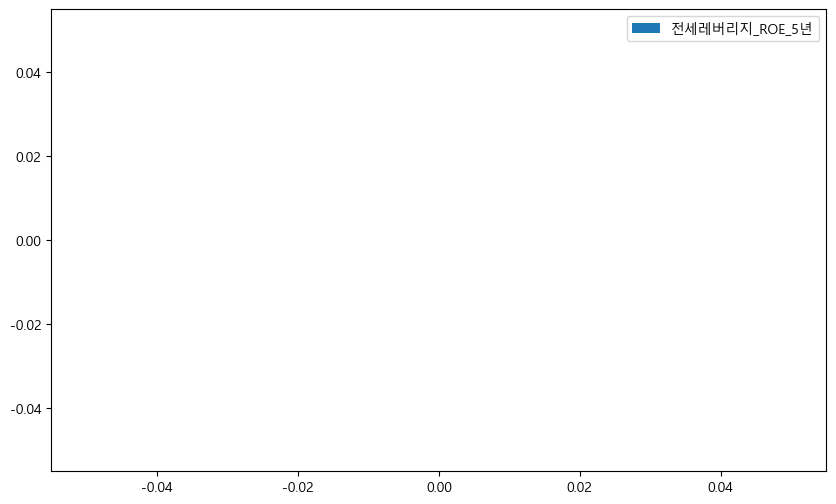

In [28]:
plot_df = result.loc[top_regions, ["전세레버리지_ROE_5년","전세레버리지_ROE_10년"]].copy()
plot_df = plot_df.sort_values("전세레버리지_ROE_10년")

ax = plot_df.plot(kind="barh", figsize=(10, 6))
ax.set_title("전세 레버리지 자기자본 수익률(ROE) 상위 지역")
ax.set_xlabel("수익률")
ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()


## 8) 해석 도구: 특정 지역(예: 영등포 vs 강남/분당) 비교

In [ ]:
def explain_region(region: str, years: int = 10):
    g = sale_rent[sale_rent["지역명"] == region].dropna().sort_values("날짜")
    if g.empty:
        return None

    end_dt = g["날짜"].iloc[-1]
    start_target = end_dt - pd.DateOffset(years=years)
    g0 = g[g["날짜"] <= start_target]
    if g0.empty:
        return None

    P0, J0 = g0[["매매지수","전세지수"]].iloc[-1]
    P1, J1 = g[["매매지수","전세지수"]].iloc[-1]
    E0, E1 = P0-J0, P1-J1

    out = {
        "기간(년)": years,
        "시작일(가까운 관측)": g0["날짜"].iloc[-1].date().isoformat(),
        "종료일": end_dt.date().isoformat(),
        "P0(매매지수)": P0,
        "P1(매매지수)": P1,
        "J0(전세지수)": J0,
        "J1(전세지수)": J1,
        "전세/매매 비율 시작(J0/P0)": J0/P0,
        "전세/매매 비율 종료(J1/P1)": J1/P1,
        "ROE": (E1/E0)-1 if E0>0 and E1>0 else np.nan,
        "매매수익률": (P1/P0)-1,
        "전세수익률": (J1/J0)-1,
    }
    return pd.Series(out)

# 예시: 관심 지역 비교
compare_regions = ["영등포구","강남구","성남시 분당구"]

cmp = pd.concat([explain_region(r, 10) for r in compare_regions if explain_region(r,10) is not None], axis=1)
cmp.columns = [c for c in compare_regions if explain_region(c,10) is not None]
cmp


In [ ]:
# 비교 시각화(정규화): 매매 vs 전세
def plot_norm(region: str):
    g = sale_rent[sale_rent["지역명"]==region].dropna().sort_values("날짜").copy()
    if g.empty:
        return
    g["매매_정규화"] = g["매매지수"] / g["매매지수"].iloc[0]
    g["전세_정규화"] = g["전세지수"] / g["전세지수"].iloc[0]

    plt.figure(figsize=(10,4))
    plt.plot(g["날짜"], g["매매_정규화"], label="매매(정규화)")
    plt.plot(g["날짜"], g["전세_정규화"], label="전세(정규화)")
    plt.title(f"{region} 매매/전세 지수 추이(정규화)")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

for r in compare_regions:
    plot_norm(r)


## 9) 내 코드/전개 방향에서 보완하면 좋은 포인트(요약)

1. **경로 문제**  
   - 노트북은 `./data/...`를 읽고 있어 실행 환경에 따라 바로 깨질 수 있음 → 노트북 상단에 `SALE_PATH/RENT_PATH`로 고정.

2. **분석 기간 고정(2016년 이후)**  
   - 데이터가 업데이트될수록 기준이 바뀌어야 함 → 최신 날짜 기준으로 **자동으로 최근 N년**을 자르는 구조로 변경.

3. **지역 필터 기준의 일관성**  
   - 기존은 매매 기준 dash 비율만으로 `valid_regions`를 잡고 전세에 그대로 적용 →  
     매매/전세 **둘 다** 데이터 보유율(coverage)을 만족하는 지역만 남김.

4. **‘-’ 처리 후 pct_change 계산 시 주의**  
   - 결측이 많으면 주간수익률/변동성이 과대·과소평가될 수 있음 →  
     coverage 기준을 먼저 적용하고, 계산 전 `dropna`로 정리.

5. **예측(LinearRegression) 파트의 한계**  
   - 단순 시간추세 회귀는 구조적 변화를 반영하기 어렵고, 결과 해석이 과도하게 단정적이 될 수 있음 →  
     이번 버전은 “예측”보다 “전세 레버리지 ROE의 구조적 비교”에 집중.  
     (원하면 다음 단계로 ARIMA/Prophet/상태공간모형 + 교차검증으로 확장 가능)

6. **‘전세를 끼면 무조건 레버리지로 수익이 커지나?’**  
   - 핵심은 **자기자본(E=P-J)의 변화**.  
   - 매매가가 올라도 전세가가 같이 크게 오르면(E1 감소) ROE가 낮아질 수 있음 → ROE로 직접 확인.
